# Project

In [1]:
# ==================================================
# IMPORTING LIBRARIES
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# ==================================================
# HELPER FUNCTIONS
# ==================================================

def rupees(value):
    value = int(round(value))
    s = str(value)

    if len(s) > 3:
        last3 = s[-3:]
        rest = s[:-3]

        groups = []

        while len(rest) > 2:
            groups.insert(0, rest[-2:])
            rest = rest[:-2]

        if rest:
            groups.insert(0, rest)

        formatted = ",".join(groups) + "," + last3
    else:
        formatted = s

    lakh = value / 100000

    return f"₹{formatted} (Approx. {lakh:.2f} Lakh)"

def rupees_short(value):
    
    value = int(round(value))
    s = str(value)

    if len(s) > 3:
        last3 = s[-3:]
        rest = s[:-3]

        groups = []

        while len(rest) > 2:
            groups.insert(0, rest[-2:])
            rest = rest[:-2]

        if rest:
            groups.insert(0, rest)

        formatted = ",".join(groups) + "," + last3
    else:
        formatted = s

    return f"₹{formatted}"

def percent(value):
    return f"{value * 100:.2f}%"

In [3]:
#Step 1: Read the data
df=pd.read_csv('archive/Car details v3.csv')

In [4]:
#Step 2: Check shape (rows, columns)
print(df.shape)
#Step 3: See first 5 rows
print(df.head())

# ==================================================
# M1: DATA CLEANING 
# ==================================================

(8128, 13)
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.14 kmpl  1498 CC  103.52 bhp   
2  Individual       Manual   Third Owner   17.7 kmpl  1497 CC      78 bhp   
3  Individual       Manual   First Owner   23.0 kmpl  1396 CC      90 bhp   
4  Individual       Manual   First Owner   16.1 kmpl  1298 CC    88.2 bhp   

                     torque  seats  
0            190Nm@ 2000rpm    5.0  
1

In [5]:
#Check missing values
print(df.isnull().sum())

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [6]:
#Fill number columns with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(num_cols)

Index(['year', 'selling_price', 'km_driven', 'seats'], dtype='object')


In [7]:
print(df.isnull().sum())

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats              0
dtype: int64


In [8]:
#Fill text columns with most common value
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [9]:
print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


In [10]:
#Check duplicates
print(df.duplicated().sum())

1202


In [11]:
#Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.duplicated().sum())

0


In [12]:
print(df.dtypes)
print(df.head())

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.14 kmpl  14

In [13]:
print(df[['mileage', 'engine', 'max_power']].head())

      mileage   engine   max_power
0   23.4 kmpl  1248 CC      74 bhp
1  21.14 kmpl  1498 CC  103.52 bhp
2   17.7 kmpl  1497 CC      78 bhp
3   23.0 kmpl  1396 CC      90 bhp
4   16.1 kmpl  1298 CC    88.2 bhp


In [14]:
#Fix number columns
df['mileage'] = df['mileage'].str.replace(' kmpl', '')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
print(df['mileage'].dtype)
df['engine'] = df['engine'].str.replace(' CC', '')
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
print(df['engine'].dtype)
df['max_power'] = df['max_power'].str.replace(' bhp', '')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
print(df['max_power'].dtype)

float64
int64
float64


In [15]:
print(df.dtypes)

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine             int64
max_power        float64
torque            object
seats            float64
dtype: object


In [16]:
print(df.describe())

              year  selling_price     km_driven      mileage       engine  \
count  6926.000000   6.926000e+03  6.926000e+03  6839.000000  6926.000000   
mean   2013.420300   5.172707e+05  7.399568e+04    19.418279  1425.398787   
std       4.078286   5.197670e+05  5.835810e+04     3.951032   487.026967   
min    1983.000000   2.999900e+04  1.000000e+00     0.000000   624.000000   
25%    2011.000000   2.500000e+05  4.000000e+04    16.950000  1197.000000   
50%    2014.000000   4.000000e+05  7.000000e+04    19.160000  1248.000000   
75%    2017.000000   6.335000e+05  1.000000e+05    22.320000  1498.000000   
max    2020.000000   1.000000e+07  2.360457e+06    42.000000  3604.000000   

         max_power        seats  
count  6925.000000  6926.000000  
mean     87.320562     5.421600  
std      31.384119     0.972171  
min       0.000000     2.000000  
25%      68.000000     5.000000  
50%      81.800000     5.000000  
75%      99.000000     5.000000  
max     400.000000    14.000000  


In [17]:
# Fill missing values again after datatype conversion
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
# Verify missing values
print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


In [18]:
# Update column groups after datatype conversion

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical Columns:")
print(list(num_cols))
print("\nCategorical Columns:")
print(list(cat_cols))

Numerical Columns:
['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Categorical Columns:
['name', 'fuel', 'seller_type', 'transmission', 'owner', 'torque']


In [19]:
print(df.describe())

              year  selling_price     km_driven      mileage       engine  \
count  6926.000000   6.926000e+03  6.926000e+03  6926.000000  6926.000000   
mean   2013.420300   5.172707e+05  7.399568e+04    19.415035  1425.398787   
std       4.078286   5.197670e+05  5.835810e+04     3.926240   487.026967   
min    1983.000000   2.999900e+04  1.000000e+00     0.000000   624.000000   
25%    2011.000000   2.500000e+05  4.000000e+04    17.000000  1197.000000   
50%    2014.000000   4.000000e+05  7.000000e+04    19.160000  1248.000000   
75%    2017.000000   6.335000e+05  1.000000e+05    22.300000  1498.000000   
max    2020.000000   1.000000e+07  2.360457e+06    42.000000  3604.000000   

         max_power        seats  
count  6926.000000  6926.000000  
mean     87.319765     5.421600  
std      31.381923     0.972171  
min       0.000000     2.000000  
25%      68.000000     5.000000  
50%      81.800000     5.000000  
75%      99.000000     5.000000  
max     400.000000    14.000000  


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6926 entries, 0 to 6925
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6926 non-null   float64
 9   engine         6926 non-null   int64  
 10  max_power      6926 non-null   float64
 11  torque         6926 non-null   object 
 12  seats          6926 non-null   float64
dtypes: float64(3), int64(4), object(6)
memory usage: 703.6+ KB
None


In [21]:
# Mean
print("\nMean:\n")
print(df[num_cols].mean(),"\n")
# Median
print("\nMedian:\n")
print(df[num_cols].median(),"\n")
# Standard Deviation
print("\nStandard Deviation:\n")
print(df[num_cols].std(),"\n")
# Top 5 value counts for categorical columns
for col in cat_cols:
    print(f"\nTop values in {col}:\n")
    print(df[col].value_counts().head())


Mean:

year               2013.420300
selling_price    517270.678458
km_driven         73995.676437
mileage              19.415035
engine             1425.398787
max_power            87.319765
seats                 5.421600
dtype: float64 


Median:

year               2014.00
selling_price    400000.00
km_driven         70000.00
mileage              19.16
engine             1248.00
max_power            81.80
seats                 5.00
dtype: float64 


Standard Deviation:

year                  4.078286
selling_price    519766.985985
km_driven         58358.095175
mileage               3.926240
engine              487.026967
max_power            31.381923
seats                 0.972171
dtype: float64 


Top values in name:

name
Maruti Swift Dzire VDI    118
Maruti Alto 800 LXI        76
Maruti Alto LXi            69
Maruti Swift VDI           60
Maruti Swift VDI BSIV      56
Name: count, dtype: int64

Top values in fuel:

fuel
Diesel    3755
Petrol    3077
CNG         56
LPG        

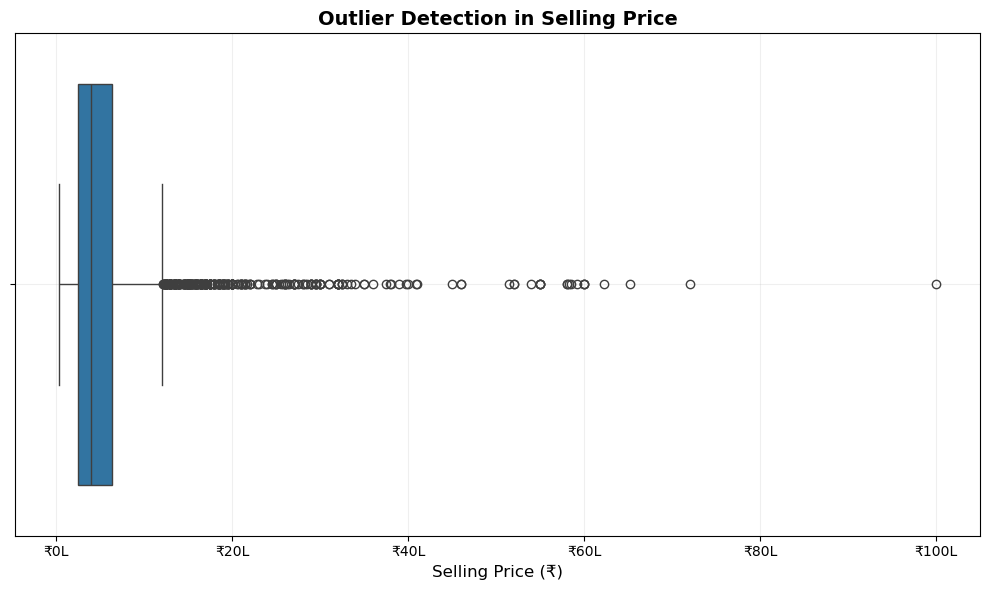

In [22]:
# Outlier Detection - Selling Price

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['selling_price']
)

plt.title('Outlier Detection in Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Selling Price (₹)', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

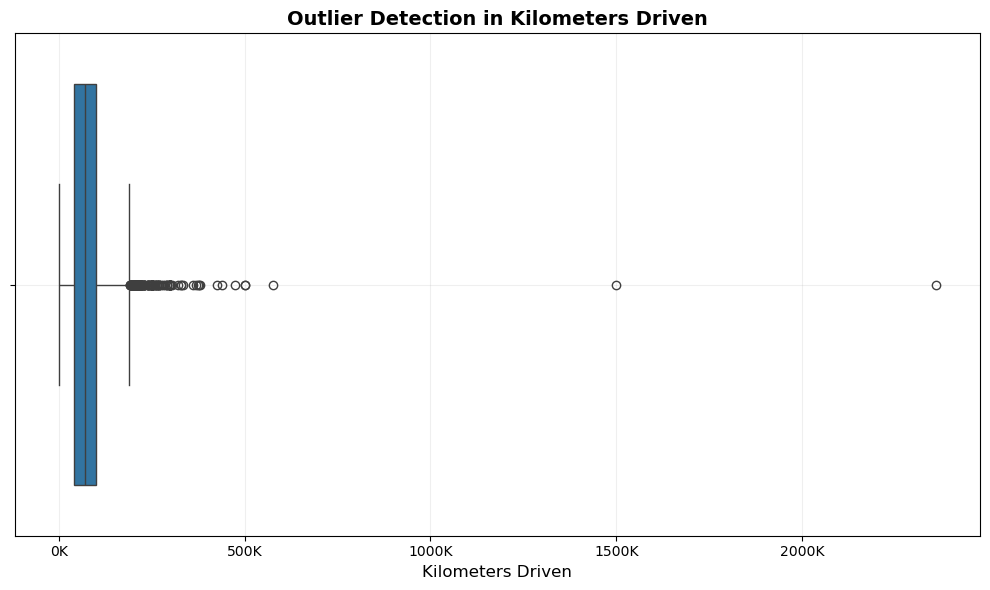

In [23]:
# Outlier Detection - Kilometers Driven

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['km_driven']
)

plt.title('Outlier Detection in Kilometers Driven', fontsize=14, fontweight='bold')
plt.xlabel('Kilometers Driven', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

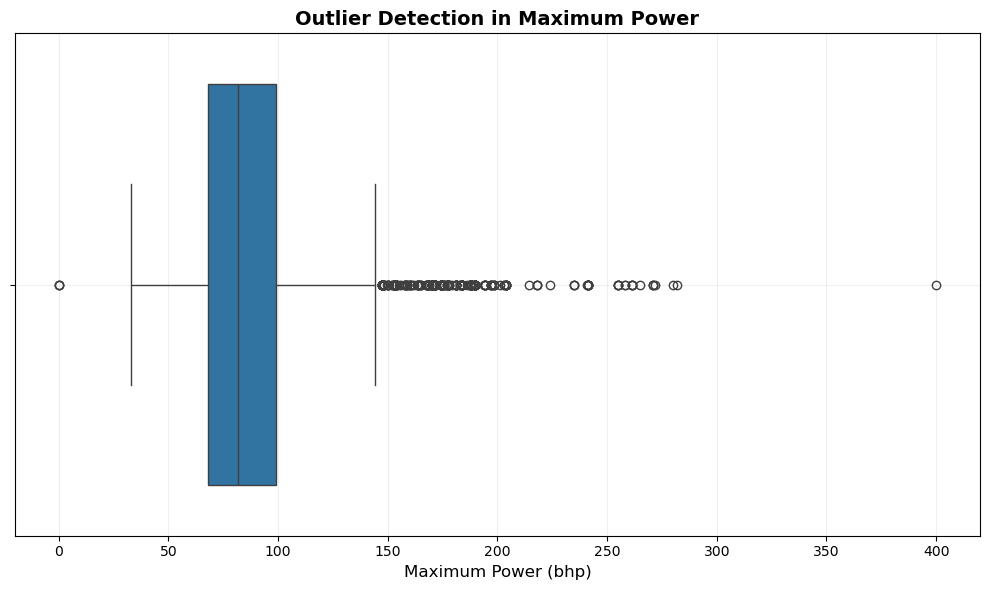

In [24]:
# Outlier Detection - Max Power

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['max_power']
)

plt.title('Outlier Detection in Maximum Power', fontsize=14, fontweight='bold')
plt.xlabel('Maximum Power (bhp)', fontsize=12)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [25]:
# ==================================================
# M1 OBSERVATIONS
# ==================================================

# 1. Missing values were successfully handled using
#    median and mode imputation techniques.

# 2. A total of 1202 duplicate records were removed
#    from the dataset.

# 3. The mileage, engine, and max_power columns were
#    converted from object type to numeric type.

# 4. Boxplots revealed the presence of outliers in
#    selling_price, km_driven, and max_power.

# 5. These outliers represent vehicles with unusually
#    high prices, mileage, or engine performance.

# 6. The dataset is now clean and ready for
#    exploratory data analysis.

In [26]:
# ==================================================
# M1: DATA CLEANING COMPLETED
# ==================================================

In [27]:
# ==================================================
# M2: EXPLORATORY DATA ANALYSIS (EDA)
# ==================================================

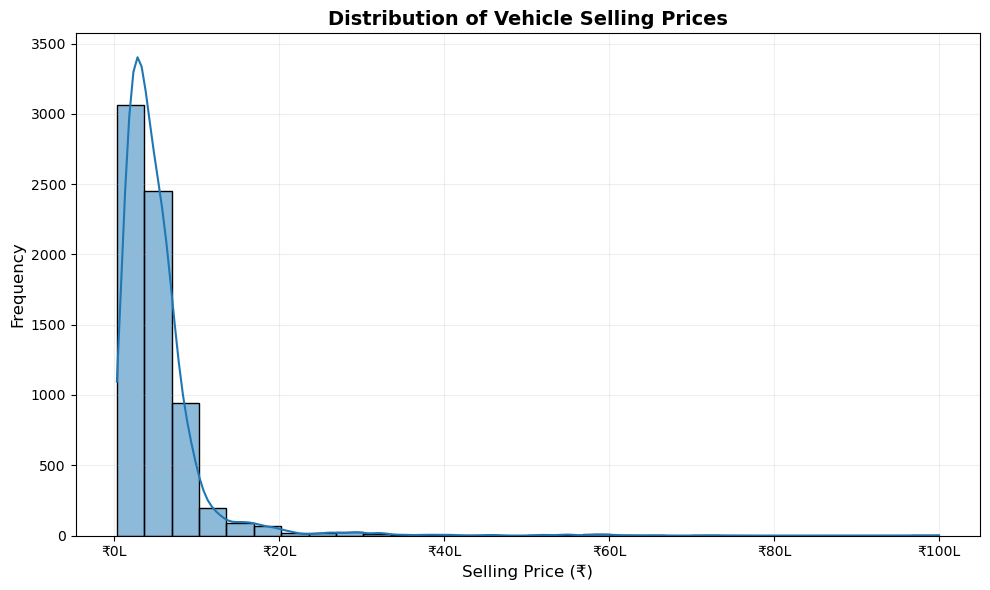

In [28]:
# Histogram of Selling Price

plt.figure(figsize=(10,6))

sns.histplot(
    df['selling_price'],
    bins=30,
    kde=True
)

plt.title('Distribution of Vehicle Selling Prices', fontsize=14, fontweight='bold')
plt.xlabel('Selling Price (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

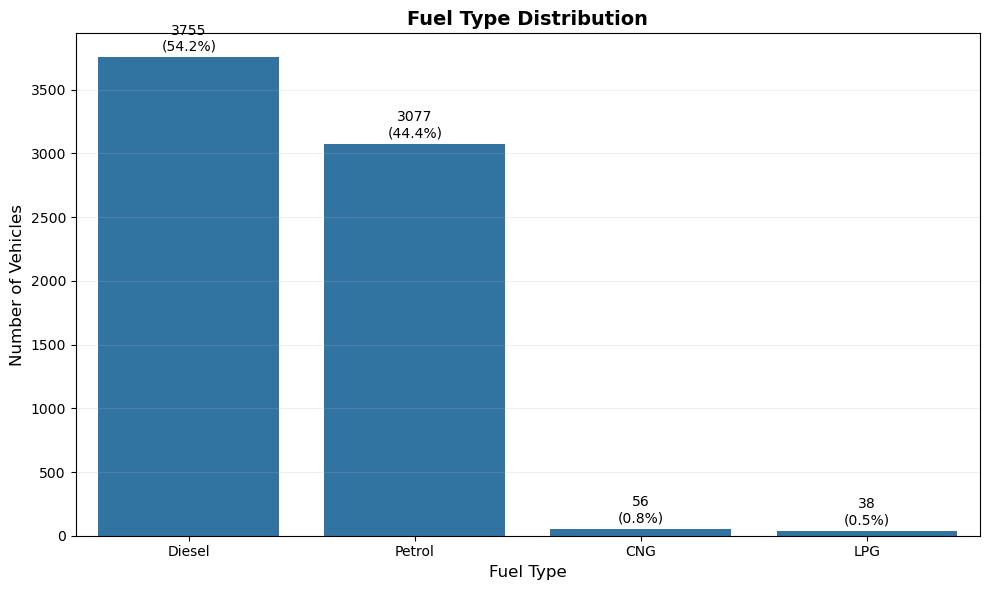

In [29]:
# Fuel Type Distribution

fuel_counts = df['fuel'].value_counts()
total = fuel_counts.sum()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=fuel_counts.index,
    y=fuel_counts.values
)

plt.title('Fuel Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)

for i, value in enumerate(fuel_counts.values):
    percentage = (value / total) * 100
    ax.text(
        i,
        value + 50,
        f"{value}\n({percentage:.1f}%)",
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

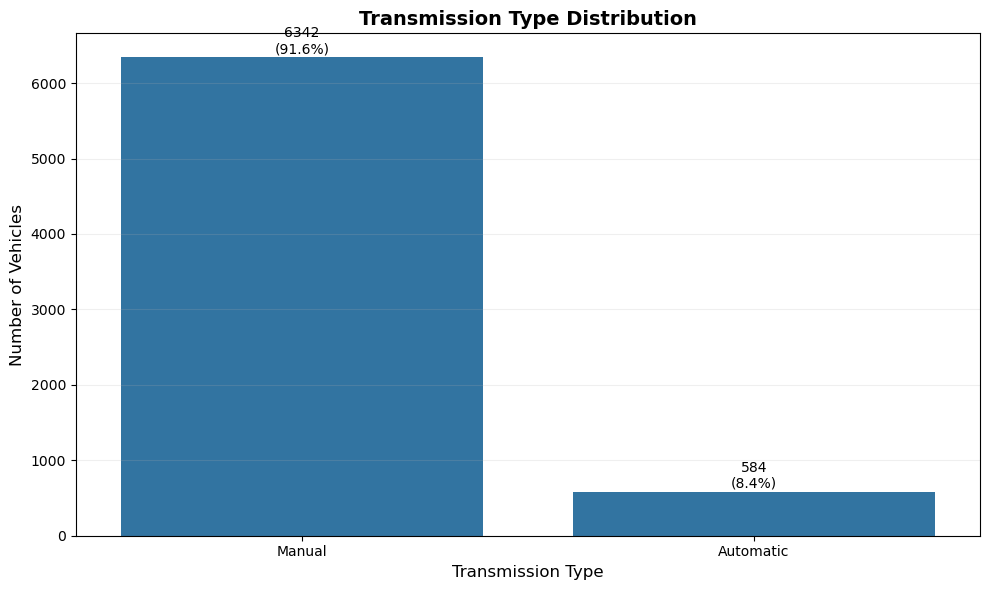

In [30]:
# Transmission Distribution

transmission_counts = df['transmission'].value_counts()
total = transmission_counts.sum()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=transmission_counts.index,
    y=transmission_counts.values
)

plt.title('Transmission Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)

for i, value in enumerate(transmission_counts.values):
    percentage = (value / total) * 100
    ax.text(
        i,
        value + 50,
        f"{value}\n({percentage:.1f}%)",
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

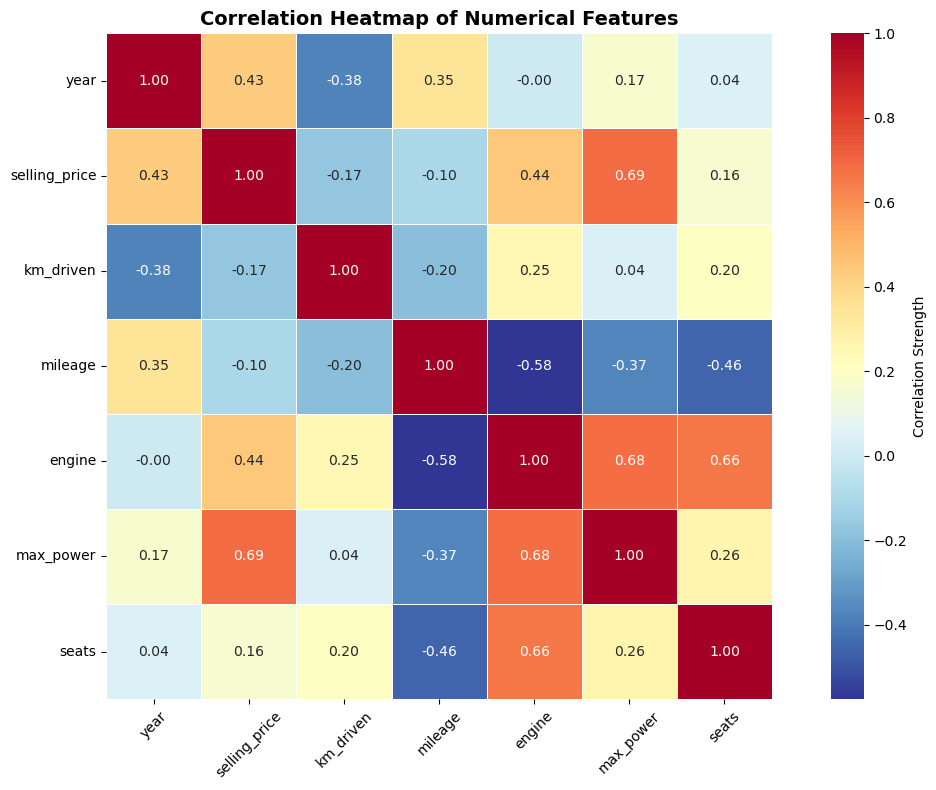

In [31]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Strength'}
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

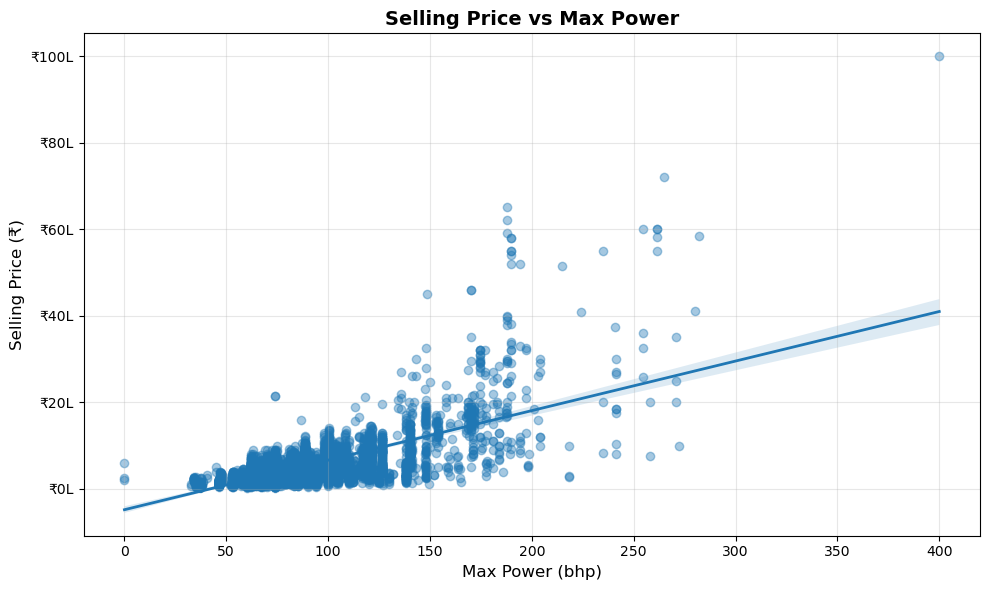

In [32]:
# Selling Price vs Max Power

plt.figure(figsize=(10,6))

sns.regplot(
    x='max_power',
    y='selling_price',
    data=df,
    scatter_kws={'alpha':0.4},
    line_kws={'linewidth':2}
)

plt.title('Selling Price vs Max Power', fontsize=14, fontweight='bold')
plt.xlabel('Max Power (bhp)', fontsize=12)
plt.ylabel('Selling Price (₹)', fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# ==================================================
# M2 OBSERVATIONS
# ==================================================

# 1. The histogram of selling_price shows a positively
#    skewed (right-skewed) distribution.

# 2. Most vehicles are concentrated in the lower
#    selling price range, while only a few luxury
#    vehicles have very high selling prices.

# 3. The mean selling price (₹5.17 lakh) is greater
#    than the median selling price (₹4 lakh),
#    confirming positive skewness.

# 4. The fuel type distribution indicates that Diesel
#    and Petrol vehicles dominate the dataset, while
#    CNG and LPG vehicles form only a small proportion.

# 5. Diesel vehicles slightly outnumber Petrol
#    vehicles in the dataset.

# 6. The transmission distribution shows that Manual
#    transmission vehicles are significantly more
#    common than Automatic transmission vehicles.

# 7. The correlation heatmap reveals that max_power
#    has the strongest positive correlation with
#    selling_price (0.69).

# 8. Engine capacity and manufacturing year show
#    moderate positive correlations with selling_price.

# 9. KM driven shows a weak negative correlation with
#    selling_price, indicating that heavily used
#    vehicles tend to have lower resale values.

# 10. The scatter plot between max_power and
#     selling_price shows a clear positive trend,
#     indicating that higher-powered vehicles tend
#     to have higher selling prices.

# 11. Based on the heatmap analysis, max_power,
#     engine, year, and km_driven are suitable
#     features for regression modelling.

# 12. The exploratory data analysis helped identify
#     important patterns, relationships, and trends
#     within the dataset.

In [34]:
# ==================================================
# M2: EXPLORATORY DATA ANALYSIS COMPLETED
# ==================================================

In [35]:
# ==================================================
# M3: PROBABILITY ANALYSIS
# ==================================================

In [36]:
# Probability of selecting a Diesel vehicle

diesel_count = len(df[df['fuel'] == 'Diesel'])
total_count = len(df)
prob_diesel = diesel_count / total_count
print("Probability of selecting a Diesel vehicle:", percent(prob_diesel))

Probability of selecting a Diesel vehicle: 54.22%


In [37]:
# Probability of selecting a Manual transmission vehicle

manual_count = len(df[df['transmission'] == 'Manual'])
total_count = len(df)
prob_manual = manual_count / total_count
print("Probability of selecting a Manual vehicle:", percent(prob_manual))

Probability of selecting a Manual vehicle: 91.57%


In [38]:
# Probability of selecting a First Owner vehicle

first_owner_count = len(df[df['owner'] == 'First Owner'])
total_count = len(df)
prob_first_owner = first_owner_count / total_count
print("Probability of selecting a First Owner vehicle:", percent(prob_first_owner))

Probability of selecting a First Owner vehicle: 61.25%


In [39]:
# Probability of selecting a Petrol vehicle

petrol_count = len(df[df['fuel'] == 'Petrol'])
total_count = len(df)
prob_petrol = petrol_count / total_count
print("Probability of selecting a Petrol vehicle:", percent(prob_petrol))

Probability of selecting a Petrol vehicle: 44.43%


In [40]:
# Probability of selecting a vehicle sold by an Individual Seller

individual_count = len(df[df['seller_type'] == 'Individual'])
total_count = len(df)
prob_individual = individual_count / total_count
print("Probability of selecting an Individual Seller vehicle:", percent(prob_individual))

Probability of selecting an Individual Seller vehicle: 89.78%


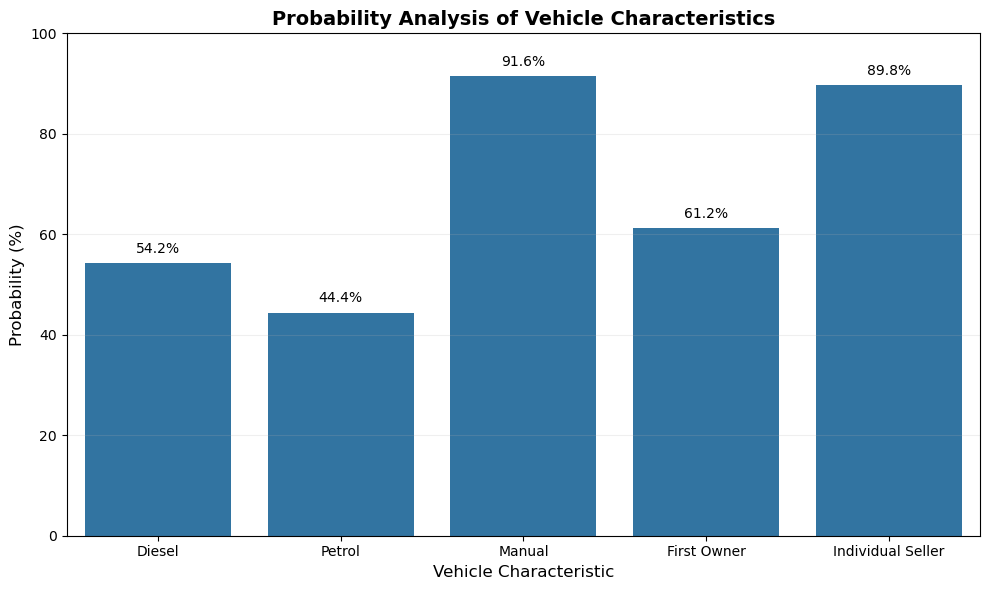

In [41]:
# Probability Distribution

labels = ['Diesel', 'Petrol', 'Manual', 'First Owner', 'Individual Seller']

probs = [
    prob_diesel * 100,
    prob_petrol * 100,
    prob_manual * 100,
    prob_first_owner * 100,
    prob_individual * 100
]

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=labels,
    y=probs
)

plt.title('Probability Analysis of Vehicle Characteristics', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Characteristic', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.ylim(0, 100)

for i, value in enumerate(probs):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [42]:
# ==================================================
# M3 OBSERVATIONS
# ==================================================

# 1. The probability of selecting a Diesel vehicle
#    is 54.22%, which is slightly higher than Petrol vehicles.

# 2. The probability of selecting a Petrol vehicle
#    is 44.42%.

# 3. Manual transmission vehicles have the highest
#    probability of occurrence (91.57%).

# 4. The probability of selecting a First Owner
#    vehicle is 61.25%.

# 5. Individual Seller vehicles have a very high
#    probability of occurrence (89.78%).

# 6. The probability distribution graph confirms that
#    Manual and Individual Seller vehicles dominate
#    the dataset.

# 7. Probability analysis helps understand the
#    likelihood of occurrence of different vehicle
#    characteristics within the dataset.

In [43]:
# ==================================================
# M3: PROBABILITY ANALYSIS COMPLETED
# ==================================================

In [44]:
# ==================================================
# M4: STATISTICAL INFERENCE
# ==================================================

In [45]:
# Confidence Interval for Average Selling Price

mean_price = df['selling_price'].mean()
std_price = df['selling_price'].std()
n = len(df)
confidence_level = 0.95
z_value = 1.96
margin_error = z_value * (std_price / np.sqrt(n))
lower_limit = mean_price - margin_error
upper_limit = mean_price + margin_error
print("Mean Selling Price:", rupees(mean_price))

print("95% Confidence Interval:")
print("Lower Limit:", rupees(lower_limit))
print("Upper Limit:", rupees(upper_limit))

Mean Selling Price: ₹5,17,271 (Approx. 5.17 Lakh)
95% Confidence Interval:
Lower Limit: ₹5,05,029 (Approx. 5.05 Lakh)
Upper Limit: ₹5,29,512 (Approx. 5.30 Lakh)


In [46]:
# One-Sample T-Test

t_stat, p_value = stats.ttest_1samp(df['selling_price'], 500000)
print("T-Statistic:", round(t_stat, 3))
print("P-Value:", round(p_value, 4))

T-Statistic: 2.765
P-Value: 0.0057


In [47]:
# ==================================================
# M4 OBSERVATIONS
# ==================================================

# 1. The mean selling price of vehicles in the dataset
#    is approximately ₹5.17 lakh.

# 2. The 95% confidence interval for the mean selling
#    price ranges from ₹5.05 lakh to ₹5.30 lakh.

# 3. This interval suggests that the true average
#    selling price is likely to lie within this range.

# 4. A one-sample t-test was performed using
#    ₹5,00,000 as the hypothesized mean.

# 5. The obtained p-value (0.0057) is less than
#    the significance level of 0.05.

# 6. Therefore, the null hypothesis is rejected.

# 7. This indicates that the average selling price
#    is significantly different from ₹5,00,000.

# 8. Statistical inference helps draw conclusions
#    about the population based on sample data.

In [48]:
# ==================================================
# M4: STATISTICAL INFERENCE COMPLETED
# ==================================================

In [49]:
# ==================================================
# M5: PREDICTIVE MODELING AND REGRESSION ANALYSIS
# ==================================================

In [50]:
# M5: Predictive Modeling and Regression Model Comparison

# In this section, multiple regression models are developed to predict the selling price of vehicles.

# The models are built using different combinations of predictor variables. Feature selection is based on the correlation heatmap and important categorical variables from the dataset.

# Each model is evaluated using:
# - Mean Absolute Error (MAE)
# - Mean Squared Error (MSE)
# - Root Mean Squared Error (RMSE)
# - R² Score

# The best model is selected based on the highest R² score and lowest prediction error.

In [51]:
# Feature Engineering and Dataset Encoding

df_model = df.copy()

# Usage Intensity Feature
df_model['km_per_year'] = (
    df_model['km_driven'] /
    (2026 - df_model['year'] + 1)
)

# Extract Brand Name
df_model['brand'] = df_model['name'].str.split().str[0]

# Extract Detailed Vehicle Model / Variant
df_model['car_model'] = (
    df_model['name']
    .str.split()
    .str[1:4]
    .str.join('_')
)

# Encode Categorical Features
categorical_cols = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand',
    'car_model'
]

df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

brand_cols = [
    col for col in df_model.columns
    if col.startswith('brand_')
]

model_cols = [
    col for col in df_model.columns
    if col.startswith('car_model_')
]

print("Encoded Dataset Shape:", df_model.shape)
print("Brand Features:", len(brand_cols))
print("Vehicle Model Features:", len(model_cols))

Encoded Dataset Shape: (6926, 1386)
Brand Features: 31
Vehicle Model Features: 1335


In [52]:
# Defining Regression Models

models = {

    "Model 1 (Max Power)": [
        'max_power'
    ],

    "Model 2 (Engine + Max Power)": [
        'engine',
        'max_power'
    ],

    "Model 3 (Engine + Max Power + Year)": [
        'engine',
        'max_power',
        'year'
    ],

    "Model 4 (Top Numerical Features)": [
        'engine',
        'max_power',
        'year',
        'km_driven'
    ],

    "Model 5 (Numerical + Mileage + Seats)": [
        'engine',
        'max_power',
        'year',
        'km_driven',
        'mileage',
        'seats'
    ],

    "Model 6 (Categorical Features Added)": [
        'engine',
        'max_power',
        'year',
        'km_driven',
        'mileage',
        'seats',
        'fuel_Diesel',
        'fuel_LPG',
        'fuel_Petrol',
        'transmission_Manual'
    ],

    "Model 7 (Seller and Owner Added)": [
        'engine',
        'max_power',
        'year',
        'km_driven',
        'mileage',
        'seats',
        'fuel_Diesel',
        'fuel_LPG',
        'fuel_Petrol',
        'transmission_Manual',
        'seller_type_Individual',
        'seller_type_Trustmark Dealer',
        'owner_Fourth & Above Owner',
        'owner_Second Owner',
        'owner_Test Drive Car',
        'owner_Third Owner'
    ],

    "Model 8 (Full Model + Brand + Vehicle Model)": (
        [
            'engine',
            'max_power',
            'year',
            'km_driven',
            'km_per_year',
            'mileage',
            'seats',
            'fuel_Diesel',
            'fuel_LPG',
            'fuel_Petrol',
            'transmission_Manual',
            'seller_type_Individual',
            'seller_type_Trustmark Dealer',
            'owner_Fourth & Above Owner',
            'owner_Second Owner',
            'owner_Test Drive Car',
            'owner_Third Owner'
        ]
        + brand_cols
        + model_cols
    )
}

In [53]:
# Function to Evaluate Regression Models

def evaluate_model(features):

    X = df_model[features]
    y = df_model['selling_price']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

In [54]:
# Evaluating All Regression Models

results = []

for model_name, features in models.items():

    mae, mse, rmse, r2 = evaluate_model(features)

    results.append([
        model_name,
        len(features),
        mae,
        mse,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'No. of Features',
        'MAE',
        'MSE',
        'RMSE',
        'R² Score'
    ]
)

results_df = results_df.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

results_df

,Model,No. of Features,MAE,MSE,RMSE,R² Score
0,Model 8 (Full Model + Brand + Vehicle Model),1383,87968.939199,4.298153e+10,207319.863327,0.804025
1,Model 6 (Categorical Features Added),10,171914.567342,9.588172e+10,309647.738145,0.562826
2,Model 3 (Engine + Max Power + Year),3,176111.563418,9.612484e+10,310040.067728,0.561717
3,Model 7 (Seller and Owner Added),16,171757.018231,9.933752e+10,315178.553879,0.547069
4,Model 5 (Numerical + Mileage + Seats),6,176972.495922,9.952407e+10,315474.350673,0.546219
5,Model 4 (Top Numerical Features),4,178530.440321,9.980690e+10,315922.306435,0.544929
6,Model 1 (Max Power),1,216891.738227,1.235895e+11,351553.048577,0.436492
7,Model 2 (Engine + Max Power),2,216994.456583,1.239172e+11,352018.720512,0.434998


In [55]:
# Clean Final Model Comparison Table

display_df = results_df.copy()

display_df['MAE'] = display_df['MAE'].apply(rupees_short)
display_df['MSE'] = display_df['MSE'].apply(lambda x: f"{int(round(x)):,}")
display_df['RMSE'] = display_df['RMSE'].apply(rupees_short)
display_df['R² Score'] = display_df['R² Score'].apply(lambda x: f"{x:.3f}")

display_df

,Model,No. of Features,MAE,MSE,RMSE,R² Score
0,Model 8 (Full Model + Brand + Vehicle Model),1383,"₹87,969","42,981,525,730","₹2,07,320",0.804
1,Model 6 (Categorical Features Added),10,"₹1,71,915","95,881,721,738","₹3,09,648",0.563
2,Model 3 (Engine + Max Power + Year),3,"₹1,76,112","96,124,843,597","₹3,10,040",0.562
3,Model 7 (Seller and Owner Added),16,"₹1,71,757","99,337,520,826","₹3,15,179",0.547
4,Model 5 (Numerical + Mileage + Seats),6,"₹1,76,972","99,524,065,932","₹3,15,474",0.546
5,Model 4 (Top Numerical Features),4,"₹1,78,530","99,806,903,703","₹3,15,922",0.545
6,Model 1 (Max Power),1,"₹2,16,892","123,589,545,964","₹3,51,553",0.436
7,Model 2 (Engine + Max Power),2,"₹2,16,994","123,917,179,591","₹3,52,019",0.435


In [56]:
# Best Model Selection Summary

best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R² Score']
best_rmse = results_df.iloc[0]['RMSE']
best_mae = results_df.iloc[0]['MAE']

best_model_summary = pd.DataFrame({
    'Metric': [
        'Best Model',
        'R² Score',
        'RMSE',
        'MAE'
    ],
    'Value': [
        'Model 8',
        f"{best_r2:.3f}",
        rupees_short(best_rmse),
        rupees_short(best_mae)
    ]
})

best_model_summary

,Metric,Value
0,Best Model,Model 8
1,R² Score,0.804
2,RMSE,"₹2,07,320"
3,MAE,"₹87,969"


In [57]:
# ==================================================
# M5 OBSERVATIONS
# ==================================================

# 1. Eight regression models were developed using
#    different combinations of numerical,
#    categorical, and engineered features.

# 2. Prediction accuracy improved gradually as
#    additional relevant features were added to
#    the models.

# 3. Feature engineering was performed by extracting
#    vehicle brand information and detailed vehicle
#    model/variant information from the name column.

# 4. The engineered features significantly improved
#    the predictive performance of the regression
#    models.

# 5. Model 8 achieved the highest performance with
#    an R² Score of approximately 0.80.

# 6. The final model was able to explain nearly
#    80% of the variation in vehicle selling prices.

In [58]:
# ==================================================
# M5: REGRESSION ANALYSIS COMPLETED
# ==================================================

In [59]:
# ==================================================
# M6: MODEL VISUALIZATION AND PERFORMANCE DASHBOARD
# ==================================================

In [60]:
# Training the Best Model

best_features = models[best_model_name]

X = df_model[best_features]
y = df_model['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

best_model = LinearRegression()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

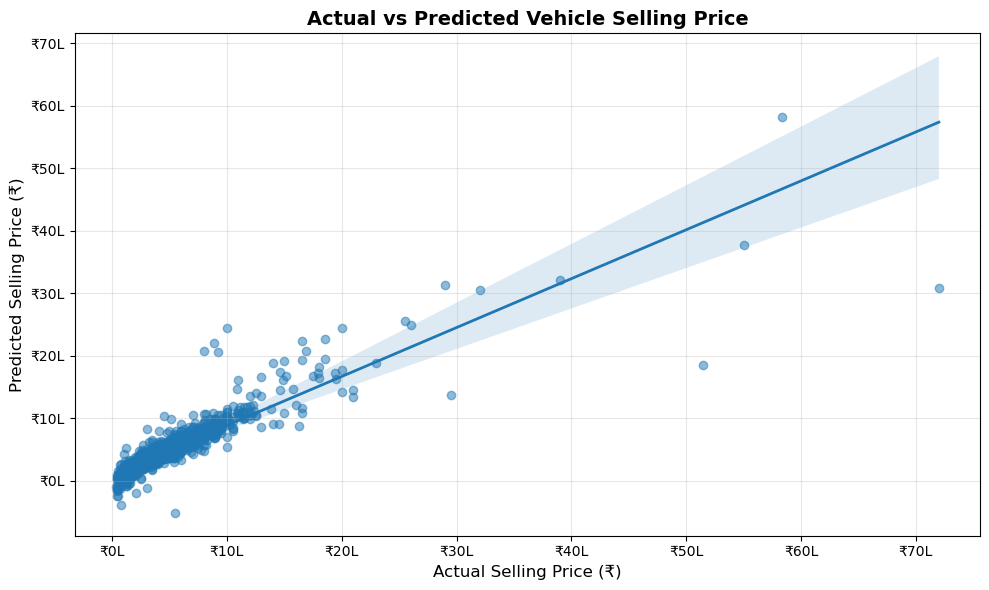

In [61]:
# Actual vs Predicted Selling Price

plt.figure(figsize=(10,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'alpha':0.5},
    line_kws={'linewidth':2}
)

plt.title('Actual vs Predicted Vehicle Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Actual Selling Price (₹)', fontsize=12)
plt.ylabel('Predicted Selling Price (₹)', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
# Final Model Performance Dashboard

print("="*60)
print("FINAL MODEL PERFORMANCE DASHBOARD")
print("="*60)
dashboard = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Features Used',
        'Best Model',
        'R² Score',
        'RMSE',
        'MAE'
    ],
    'Value': [
        df.shape[0],
        len(best_features),
        'Model 8',
        round(best_r2, 3),
        rupees_short(best_rmse),
        rupees_short(best_mae)
    ]
})

dashboard

FINAL MODEL PERFORMANCE DASHBOARD


,Metric,Value
0,Total Records,6926
1,Total Features Used,1383
2,Best Model,Model 8
3,R² Score,0.804
4,RMSE,"₹2,07,320"
5,MAE,"₹87,969"


In [63]:
# ==================================================
# M6 OBSERVATIONS
# ==================================================

# 1. The Actual vs Predicted plot showed a strong
#    positive relationship between actual and
#    predicted vehicle selling prices.

# 2. Most observations were concentrated near the
#    regression trend line, indicating good model
#    performance.

# 3. The final regression model achieved an
#    R² Score of approximately 0.80.

# 4. The dashboard summarized important project
#    metrics including model accuracy, RMSE,
#    MAE, and total features used.

# 5. The results confirm that feature engineering
#    played a major role in improving prediction
#    performance.

# 6. The developed model can be used as a reliable
#    tool for estimating vehicle selling prices.

In [64]:
# ==================================================
# M6: FINAL MODEL VISUALIZATION COMPLETED
# ==================================================

In [65]:
# ==================================================
# PROJECT CONCLUSION
# ==================================================

# 1. Vehicle selling price prediction was performed
#    using data cleaning, exploratory data analysis,
#    feature engineering, and regression modeling.

# 2. Multiple regression models were compared to
#    identify the most accurate prediction model.

# 3. Feature engineering using brand and detailed
#    vehicle model information significantly
#    improved prediction accuracy.

# 4. The final regression model achieved an
#    R² Score of approximately 0.80.

# 5. The project successfully demonstrated the
#    application of data science techniques for
#    solving a real-world vehicle price prediction
#    problem.

# ==================================================